In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/features/nifty_50_features_with_regimes.csv",
    parse_dates=["Date"],
    index_col="Date"
)

df.columns


Index(['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'log_return',
       'vol_20d', 'cluster_regime', 'vol_z'],
      dtype='str')

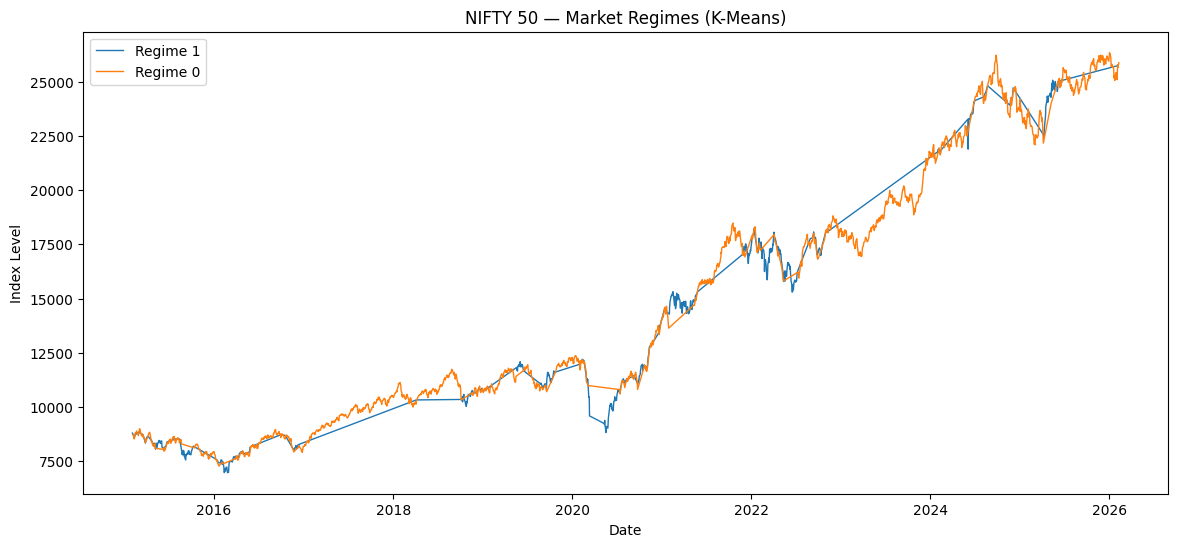

In [10]:
plt.figure(figsize=(14,6))

for regime in df["cluster_regime"].dropna().unique():
    subset = df[df["cluster_regime"] == regime]
    plt.plot(
        subset.index,
        subset["Close"],
        label=f"Regime {int(regime)}",
        linewidth=1
    )

plt.title("NIFTY 50 — Market Regimes (K-Means)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.show()


In [11]:
df.groupby("cluster_regime")["vol_20d"].mean()


cluster_regime
0.0    0.110581
1.0    0.206716
Name: vol_20d, dtype: float64

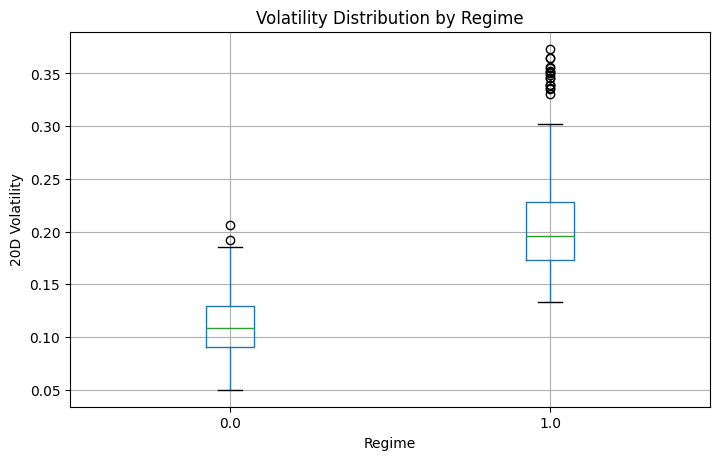

In [12]:
df.boxplot(
    column="vol_20d",
    by="cluster_regime",
    figsize=(8,5)
)

plt.title("Volatility Distribution by Regime")
plt.suptitle("")
plt.xlabel("Regime")
plt.ylabel("20D Volatility")
plt.show()


In [ ]:
df.groupby("cluster_regime")["daily_return"].mean()

cluster_regime
0.0   -0.000465
1.0    0.003433
Name: daily_return, dtype: float64

In [ ]:
df.groupby("cluster_regime").agg(
    avg_return=("daily_return", "mean"),
    volatility=("daily_return", "std")
)

,avg_return,volatility
cluster_regime,,
0.0,-0.000465,0.007345
1.0,0.003433,0.012764


In [ ]:
df["cum_return"] = (1 + df["daily_return"]).cumprod()

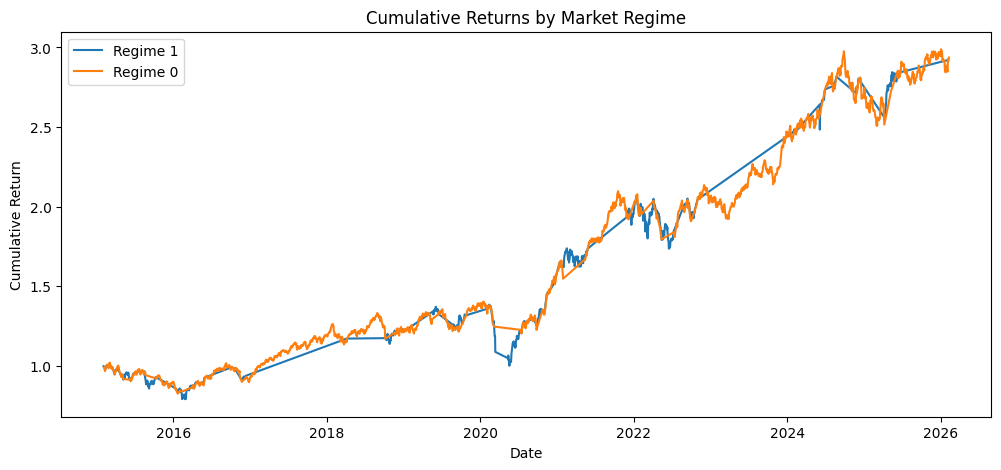

In [16]:
plt.figure(figsize=(12,5))

for regime in df["cluster_regime"].dropna().unique():
    subset = df[df["cluster_regime"] == regime]
    plt.plot(
        subset.index,
        subset["cum_return"],
        label=f"Regime {int(regime)}"
    )

plt.title("Cumulative Returns by Market Regime")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()


1Market exhibits two persistent regimes
2High-volatility regime shows lower average returns and shorter persistence
3Low-volatility regime dominates long-term growth
4Regime transitions are asymmetric 

In [17]:
df["rolling_max"] = df["cum_return"].cummax()
df["drawdown"] = df["cum_return"] / df["rolling_max"] - 1

df.groupby("cluster_regime")["drawdown"].min()


cluster_regime
0.0   -0.191130
1.0   -0.286278
Name: drawdown, dtype: float64

insights
The NIFTY 50 exhibits two persistent market regimes identified via unsupervised clustering.

Regime 0 is characterized by lower volatility, smaller drawdowns (~19%), and dominates long-term cumulative returns.

Regime 1 captures stress periods, with significantly higher volatility and deeper drawdowns (~29%).

Regime transitions are not random; regimes show persistence over weeks to months.

This suggests regime-aware strategies could improve risk management and capital allocation.

limitation
Analysis is based on a single index (NIFTY 50); results may differ for individual stocks.

K-Means assumes convex clusters and may not capture nonlinear regime boundaries.

Regimes are identified using historical data and are not predictive guarantees.

Transaction costs and real-world execution constraints are not modeled.